<a href="https://colab.research.google.com/github/RinDataz/Playground/blob/main/AML_Project_Emotion_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

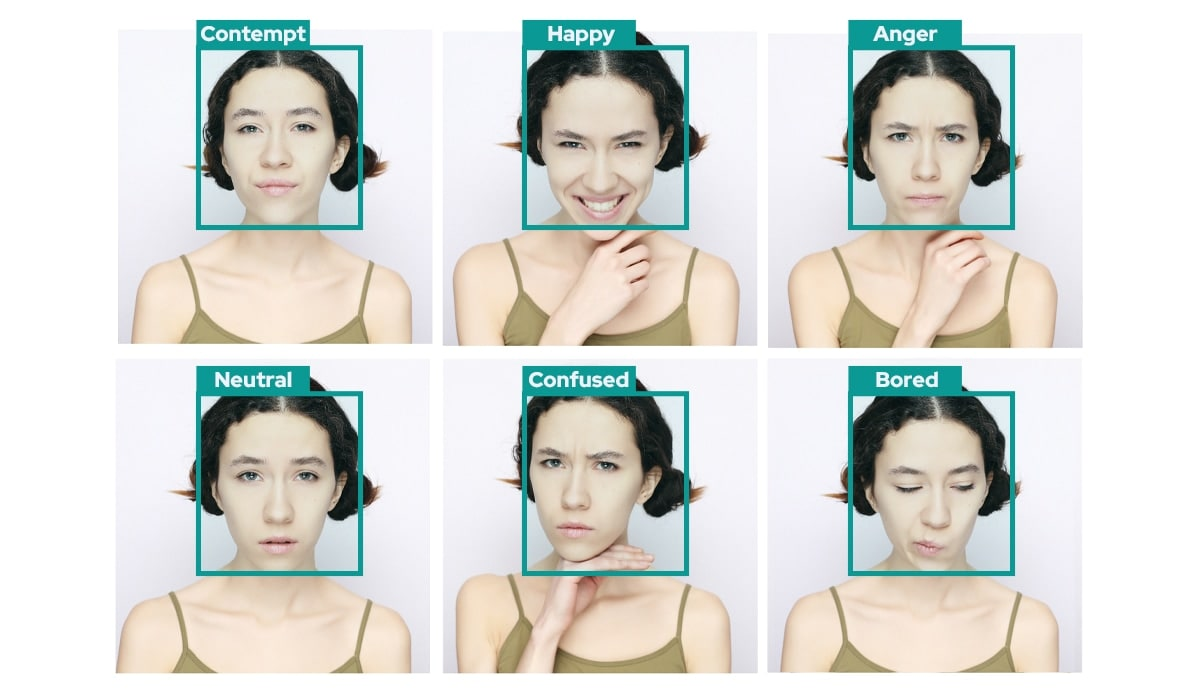

# Emotion detection

# API Preparation


Rinad

In [8]:
!pip install -q kaggle

In [9]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [10]:
!kaggle datasets list -s "fer2013"

ref                                                           title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
deadskull7/fer2013                                            fer2013                                             101279992  2018-05-26 12:18:24.933000          53673        529  0.29411766       
nicolejyt/facialexpressionrecognition                         FER2013                                             101279992  2019-04-02 18:29:26.050000           9749         54  0.3529412        
astraszab/facial-expression-dataset-image-folders-fer2013     Facial expression dataset image folders (fer2013)    68268497  2020-04-14 08:15:32.013000           4537         63  0.5625           
subhaditya/fer2

In [11]:
!kaggle datasets download -d msambare/fer2013 -p /content/kaggle_data

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0


In [12]:
!unzip /content/kaggle_data/fer2013.zip -d /content/kaggle_data

Streaming output truncated to the last 5000 lines.
  inflating: /content/kaggle_data/train/sad/Training_65242339.jpg  
  inflating: /content/kaggle_data/train/sad/Training_65267116.jpg  
  inflating: /content/kaggle_data/train/sad/Training_65275626.jpg  
  inflating: /content/kaggle_data/train/sad/Training_6529266.jpg  
  inflating: /content/kaggle_data/train/sad/Training_65329617.jpg  
  inflating: /content/kaggle_data/train/sad/Training_65338712.jpg  
  inflating: /content/kaggle_data/train/sad/Training_65338797.jpg  
  inflating: /content/kaggle_data/train/sad/Training_65387162.jpg  
  inflating: /content/kaggle_data/train/sad/Training_65404494.jpg  
  inflating: /content/kaggle_data/train/sad/Training_65426218.jpg  
  inflating: /content/kaggle_data/train/sad/Training_65430136.jpg  
  inflating: /content/kaggle_data/train/sad/Training_65437377.jpg  
  inflating: /content/kaggle_data/train/sad/Training_6545735.jpg  
  inflating: /content/kaggle_data/train/sad/Training_65463385.jpg  

# Data Preprocessing and EDA

Shaden

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

^^ note from rinad : this is not needed

In [13]:
import os  # to deal with folders
import cv2  # to read and transform images
import numpy as np  # to deal with matrices, prepare images and labels
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# define emotions labels
emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

# set the directory path (can be 'train' or 'test')
base_dir = '/content/kaggle_data/train'
augmentation_threshold = 5000  # minimum images per class


Number of images per category:

angry: 3995 images
disgust: 436 images
fear: 4097 images
happy: 7215 images
sad: 4830 images
surprise: 3171 images
neutral: 4965 images

Image shapes per category:
angry: (48, 48)
disgust: (48, 48)
fear: (48, 48)
happy: (48, 48)
sad: (48, 48)
surprise: (48, 48)
neutral: (48, 48)

Displaying sample images:


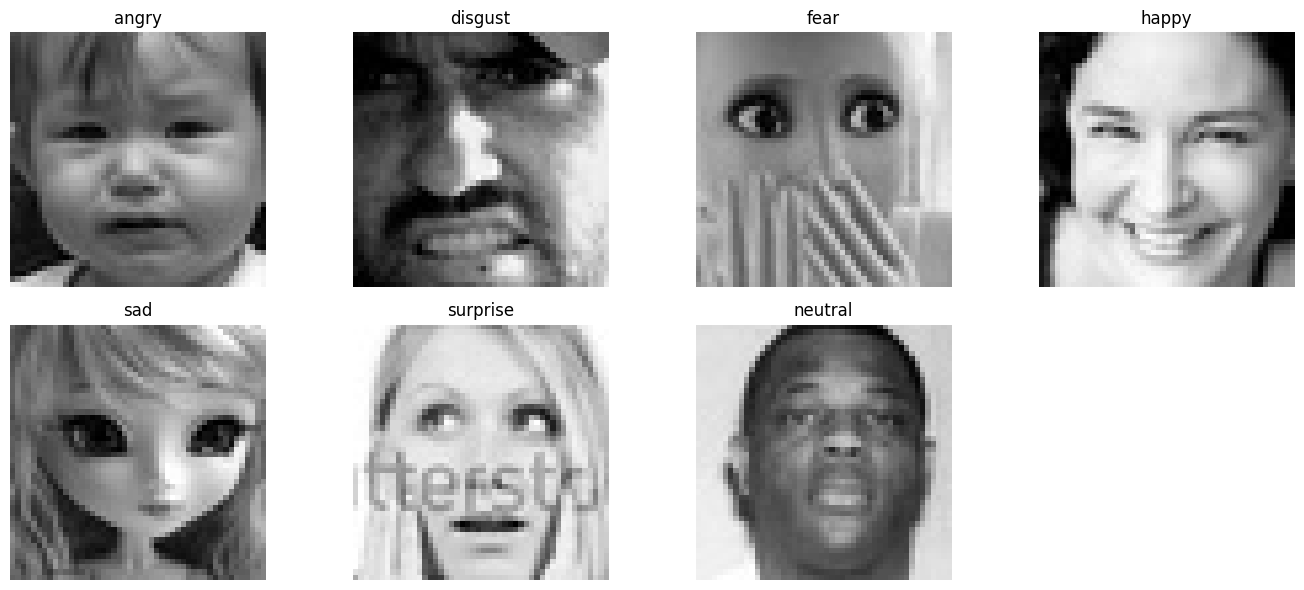


Applying augmentation to classes with fewer than 5000 images...

angry: augmenting 1005 images...
disgust: augmenting 4564 images...
fear: augmenting 903 images...
sad: augmenting 170 images...
surprise: augmenting 1829 images...
neutral: augmenting 35 images...


In [14]:
# 1. Count number of images in each category
print("Number of images per category:\n")
class_counts = {}
for emotion in emotion_labels:
    folder = os.path.join(base_dir, emotion)
    count = len(os.listdir(folder))
    class_counts[emotion] = count
    print(f"{emotion}: {count} images")

# 2. Check image shapes for consistency
print("\nImage shapes per category:")
for emotion in emotion_labels:
    folder = os.path.join(base_dir, emotion)
    first_img = os.listdir(folder)[0]
    img = cv2.imread(os.path.join(folder, first_img), cv2.IMREAD_GRAYSCALE)
    print(f"{emotion}: {img.shape}")

# 3. Display sample images from each category
print("\nDisplaying sample images:")
plt.figure(figsize=(14, 6))
for i, emotion in enumerate(emotion_labels):
    folder = os.path.join(base_dir, emotion)
    img_name = os.listdir(folder)[0]  # Take the first image
    img_path = os.path.join(folder, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(2, 4, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(emotion)
    plt.axis('off')
plt.tight_layout()
plt.show()

# 4. Data Augmentation for underrepresented classes
print("\nApplying augmentation to classes with fewer than 5000 images...\n")
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

for emotion in emotion_labels:
    emotion_folder = os.path.join(base_dir, emotion)
    image_files = [f for f in os.listdir(emotion_folder) if f.endswith('.png') or f.endswith('.jpg')]
    num_images = len(image_files)

    if num_images < augmentation_threshold:
        needed = augmentation_threshold - num_images
        print(f"{emotion}: augmenting {needed} images...")
        img_index = 0
        gen_count = 0
        while gen_count < needed:
            img_path = os.path.join(emotion_folder, image_files[img_index % num_images])
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None or img.shape != (48, 48):
                img_index += 1
                continue

            img = img.reshape((1, 48, 48, 1))
            for batch in datagen.flow(img, batch_size=1, save_to_dir=emotion_folder, save_prefix='aug', save_format='png'):
                gen_count += 1
                if gen_count >= needed:
                    break
            img_index += 1


In [15]:
# 5. One-hot encoding function
def one_hot(label_index, num_classes=7):
    vector = np.zeros(num_classes)
    vector[label_index] = 1
    return vector

# 6. Load dataset after augmentation
def load_dataset(folder_path):
    X, y = [], []
    for idx, emotion in enumerate(emotion_labels):
        emotion_folder = os.path.join(folder_path, emotion)
        for img_file in os.listdir(emotion_folder):
            img_path = os.path.join(emotion_folder, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (48, 48)) / 255.0
                X.append(img.reshape(48, 48, 1))
                y.append(one_hot(idx))
    return np.array(X), np.array(y)

# 7. Apply loading
X_train, y_train = load_dataset('/content/kaggle_data/train')
X_test, y_test = load_dataset('/content/kaggle_data/test')

# 8. Print final shapes
print("\nFinal dataset shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)



Final dataset shapes:
X_train: (36060, 48, 48, 1)
y_train: (36060, 7)


## Capsule Network Model

Mayar

Build Capsule Network Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# Build Capsule Network Model
def build_capsule_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # First Convolutional layer
    conv1 = layers.Conv2D(32, (3, 3), activation='relu', strides=2)(inputs)
    conv2 = layers.Conv2D(64, (3, 3), activation='relu', strides=2)(conv1)

    # Third Convolutional layer
    conv3 = layers.Conv2D(128, (3, 3), activation='relu', strides=2)(conv2)

    # Final Capsule layer
    # We will use a Flatten layer after this
    capsule = layers.Conv2D(256, (3, 3), activation='relu')(conv3)
    capsule_flatten = layers.Flatten()(capsule)

    # Fully connected layer
    dense = layers.Dense(512, activation='relu')(capsule_flatten)
    dropout = layers.Dropout(0.5)(dense)

    # Output layer: number of classes = num_classes
    output = layers.Dense(num_classes, activation='softmax')(dropout)

    # Create the model
    model = models.Model(inputs=inputs, outputs=output)

    return model

# Build the model
input_shape = (48, 48, 1)  # Images of size 48x48 with one channel (grayscale)
num_classes = 7  # Number of emotions

caps_model = build_capsule_model(input_shape, num_classes)

# Compile the model
caps_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
caps_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 23, 23, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,571,591 (6.00 MB)

 Trainable params: 1,571,591 (6.00 MB)

 Non-trainable params: 0 (0.00 B)

 Train the Model

In [ ]:
# Train the model
caps_model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

Epoch 1/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 63s 119ms/step - accuracy: 0.3694 - loss: 1.5986 - val_accuracy: 0.0000e+00 - val_loss: 2.7773
Epoch 2/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 79s 114ms/step - accuracy: 0.5673 - loss: 1.1594 - val_accuracy: 0.0105 - val_loss: 2.3767
Epoch 3/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.6074 - loss: 1.0469 - val_accuracy: 0.0568 - val_loss: 2.4094
Epoch 4/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 80s 115ms/step - accuracy: 0.6451 - loss: 0.9429 - val_accuracy: 0.0507 - val_loss: 2.4650
Epoch 5/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.6788 - loss: 0.8497 - val_accuracy: 0.1644 - val_loss: 2.3753
Epoch 6/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 79s 113ms/step - accuracy: 0.7227 - loss: 0.7532 - val_accuracy: 0.0607 - val_loss: 2.7628
Epoch 7/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 83s 116ms/step - accuracy: 0.7575 - loss: 0.6524 - val_accuracy: 0.1702 - val_loss: 2.7246
Epoch 8/10
508/508 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.7897 - los

 Evaluate the Model on Test Data

In [ ]:
loss, accuracy = caps_model.evaluate(X_test, y_test)
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5290 - loss: 1.7201
Loss: 1.8911
Accuracy: 0.5077


Display Model Predictions on New Images

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


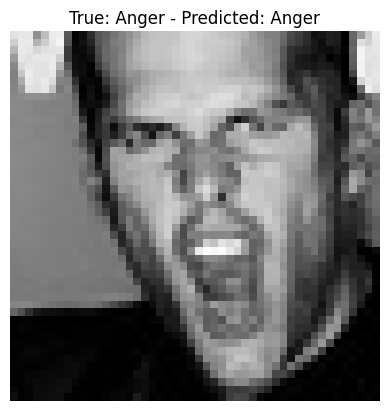

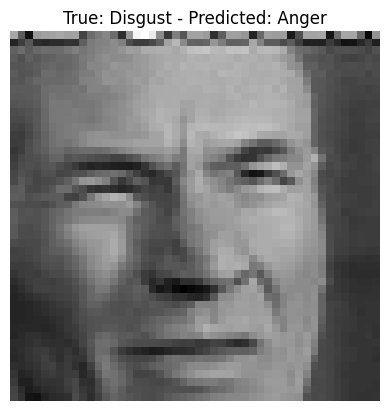

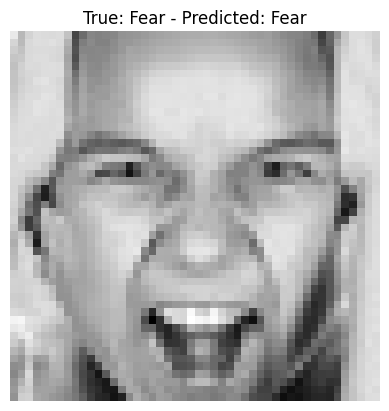

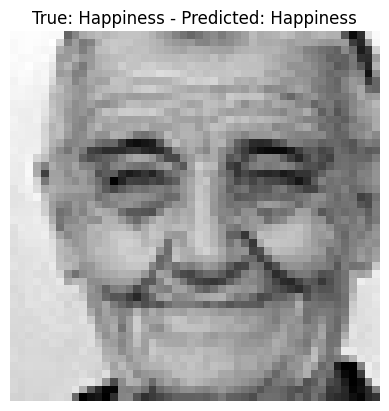

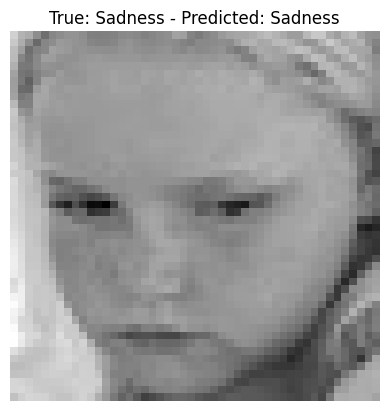

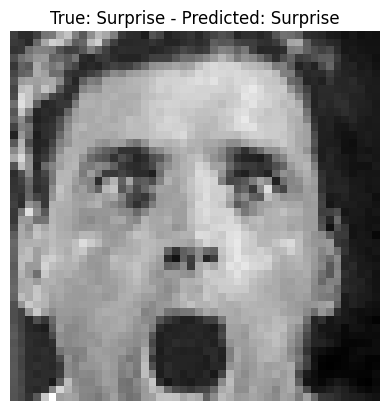

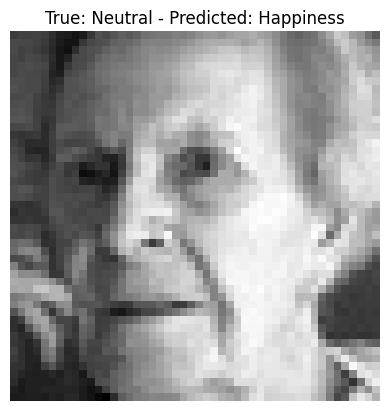

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Predict the results
predictions = caps_model.predict(X_test)

# List of emotions
emotion_labels = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Sadness', 'Surprise', 'Neutral']

# To store the first image shown for each class
shown = {}

# Iterate over the test dataset
for index in range(len(X_test)):
    true_class = np.argmax(y_test[index])
    if true_class not in shown:
        plt.imshow(X_test[index].reshape(48, 48), cmap='gray')
        true_label = emotion_labels[true_class]
        predicted_label = emotion_labels[np.argmax(predictions[index])]
        plt.title(f"True: {true_label} - Predicted: {predicted_label}")
        plt.axis('off')
        plt.show()
        shown[true_class] = True
    if len(shown) == len(emotion_labels):
        break

Show Full Performance Report

In [ ]:
from sklearn.metrics import classification_report

# Convert predictions and true labels from one-hot to class indices
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(predictions, axis=1)

# Print performance report
print(classification_report(y_true, y_pred, target_names=[
    'Anger', 'Disgust', 'Fear', 'Happiness', 'Sadness', 'Surprise', 'Neutral'
]))

              precision    recall  f1-score   support

       Anger       0.39      0.49      0.43       958
     Disgust       0.72      0.37      0.49       111
        Fear       0.33      0.43      0.38      1024
   Happiness       0.70      0.75      0.73      1774
     Sadness       0.37      0.45      0.41      1247
    Surprise       0.66      0.71      0.68       831
     Neutral       0.68      0.18      0.28      1233

    accuracy                           0.51      7178
   macro avg       0.55      0.48      0.48      7178
weighted avg       0.54      0.51      0.50      7178



Plot the Confusion Matrix

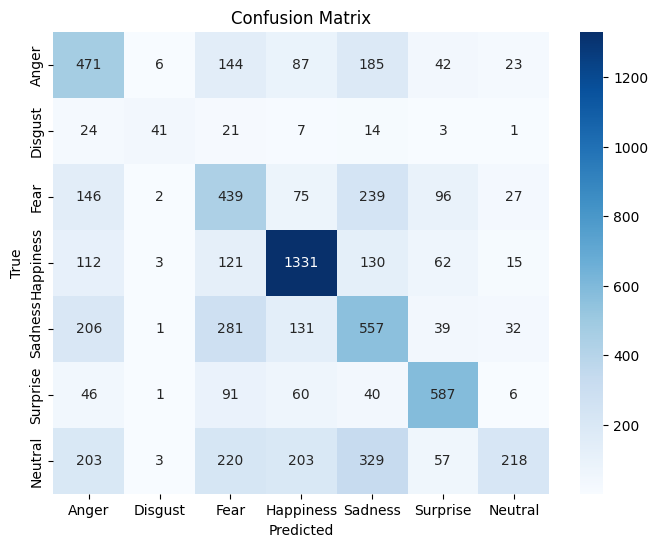

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Anger', 'Disgust', 'Fear', 'Happiness', 'Sadness', 'Surprise', 'Neutral'],
            yticklabels=['Anger', 'Disgust', 'Fear', 'Happiness', 'Sadness', 'Surprise', 'Neutral'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# CNN Model

Mayar

Step 1: Build the CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint

# Build the CNN model
model = Sequential()

# Convolutional layers
model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(48, 48, 1)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Flatten layer
model.add(Flatten())

# Fully connected layers
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7, activation='softmax'))  # 7 classes (emotions)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Save the best model using ModelCheckpoint
checkpoint = ModelCheckpoint('best_emotion_model.h5', monitor='val_loss', save_best_only=True, mode='min')

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test), callbacks=[checkpoint])

Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.3656 - loss: 1.6067

563/563 ━━━━━━━━━━━━━━━━━━━━ 353s 622ms/step - accuracy: 0.3657 - loss: 1.6063 - val_accuracy: 0.4500 - val_loss: 1.4362
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.5807 - loss: 1.1133

563/563 ━━━━━━━━━━━━━━━━━━━━ 387s 631ms/step - accuracy: 0.5807 - loss: 1.1132 - val_accuracy: 0.5022 - val_loss: 1.2994
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.6247 - loss: 0.9920

563/563 ━━━━━━━━━━━━━━━━━━━━ 366s 603ms/step - accuracy: 0.6247 - loss: 0.9920 - val_accuracy: 0.5316 - val_loss: 1.2331
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.6657 - loss: 0.8914

563/563 ━━━━━━━━━━━━━━━━━━━━ 354s 628ms/step - accuracy: 0.6657 - loss: 0.8914 - val_accuracy: 0.5568 - val_loss: 1.1717
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.6990 - loss: 0.8096

563/563 ━━━━━━━━━━━━━━━━━━━━ 349s 620ms/step - accuracy: 0.6990 - loss: 0.8096 - val_accuracy: 0.5688 - val_loss: 1.1470
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 385s 625ms/step - accuracy: 0.7262 - loss: 0.7369 - val_accuracy: 0.5804 - val_loss: 1.1594
Epoch 7/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 346s 615ms/step - accuracy: 0.7597 - loss: 0.6515 - val_accuracy: 0.5862 - val_loss: 1.1547
Epoch 8/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 376s 605ms/step - accuracy: 0.7946 - loss: 0.5658 - val_accuracy: 0.5896 - val_loss: 1.2223
Epoch 9/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 378s 598ms/step - accuracy: 0.8235 - loss: 0.4870 - val_accuracy: 0.5889 - val_loss: 1.2386
Epoch 10/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 386s 604ms/step - accuracy: 0.8535 - loss: 0.4073 - val_accuracy: 0.5935 - val_loss: 1.3563
Epoch 11/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 380s 601ms/step - accuracy: 0.8762 - loss: 0.3437 - val_accuracy: 0.5932 - val_loss: 1.3966
Epoch 12/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 390s 615ms/step - accuracy: 0.8944 - loss: 0

Step 2: Load the Trained Model and Use it for Prediction

----------------------------
# Rinad

In [16]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [17]:
# Define an improved model architecture
model = Sequential([
    # First convolutional block - increasing filters
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(48, 48, 1)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Second convolutional block - deeper network
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Third convolutional block
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Flatten and dense layers
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

# Compile
optimizer = Adam(learning_rate=0.0005)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# callbacks
filepath = 'best_emotion_model.h5'
checkpoint = ModelCheckpoint(
    filepath=filepath,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

#  early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

#  learning rate scheduler to adjust learning rate during training
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

callbacks_list = [checkpoint, early_stopping, reduce_lr]

# more epochs but early stopping decide when to stop
epochs = 100  # Maximum epochs, early stopping will likely trigger before this
batch_size = 32  # Smaller batch size often helps with generalization

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    shuffle=True,
    callbacks=callbacks_list
)

Epoch 1/100
 133/1127 ━━━━━━━━━━━━━━━━━━━━ 33:25 2s/step - accuracy: 0.2529 - loss: 2.6128

In [ ]:
# Evaluate the best model
best_model = keras.models.load_model('best_emotion_model.h5')
loss, accuracy = best_model.evaluate(X_test, y_test, verbose=1)
print(f'\nBest Model Test Loss: {loss:.4f}')
print(f'Best Model Test Accuracy: {accuracy:.4f}')


In [ ]:
# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import tensorflow as tf
from tensorflow.keras.models import Model
import pandas as pd

# Assuming model, X_test, y_test are already defined
# Also assuming emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

def plot_confusion_matrix(model, X_test, y_test, class_names):
    # Get predictions and true labels
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)

    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title('Normalized Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return y_pred, y_true


In [ ]:

# 2. Per-Class Metrics Visualization
def plot_per_class_metrics(y_true, y_pred, class_names):
    # Get classification report as dictionary
    y_pred_classes = np.argmax(y_pred, axis=1)
    report = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)

    # Convert to DataFrame for easier visualization
    df_report = pd.DataFrame(report).transpose()

    # Plot precision, recall, and f1-score for each class
    plt.figure(figsize=(12, 6))
    df_metrics = df_report.iloc[:-3]  # Exclude avg rows

    # Plot as grouped bar chart
    df_metrics[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(12, 6))
    plt.title('Precision, Recall, and F1-Score per Emotion Class')
    plt.ylabel('Score')
    plt.xlabel('Emotion')
    plt.xticks(rotation=45)
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    return df_report

# 3. ROC Curves for Multi-Class Classification
def plot_roc_curves(y_test, y_pred, class_names):
    # Compute ROC curve and ROC area for each class
    y_test_bin = label_binarize(np.argmax(y_test, axis=1), classes=range(len(class_names)))
    n_classes = y_test_bin.shape[1]

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curves
    plt.figure(figsize=(12, 10))
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink'])

    for i, color, cls in zip(range(n_classes), colors, class_names):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{cls} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC Curves')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

# 4. Learning Curves (Training vs Validation over Epochs)
def plot_detailed_learning_curves(history):
    # Create more detailed learning curves
    plt.figure(figsize=(15, 7))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], 'o-', label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], 'o-', label='Validation Accuracy')

    # Find best epoch
    best_epoch = np.argmax(history.history['val_accuracy'])
    best_val_acc = history.history['val_accuracy'][best_epoch]
    plt.axvline(x=best_epoch, color='r', linestyle='--',
                label=f'Best Epoch: {best_epoch+1}, Acc: {best_val_acc:.4f}')

    plt.title('Accuracy Learning Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], 'o-', label='Training Loss')
    plt.plot(history.history['val_loss'], 'o-', label='Validation Loss')

    # Find best epoch
    best_epoch_loss = np.argmin(history.history['val_loss'])
    best_val_loss = history.history['val_loss'][best_epoch_loss]
    plt.axvline(x=best_epoch_loss, color='r', linestyle='--',
                label=f'Best Epoch: {best_epoch_loss+1}, Loss: {best_val_loss:.4f}')

    plt.title('Loss Learning Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# 5. Visualize Feature Maps
def visualize_feature_maps(model, img, layer_name):
    # Create a model that outputs feature maps for a specific layer
    layer_outputs = [layer.output for layer in model.layers if layer_name in layer.name]
    if not layer_outputs:
        print(f"No layer found with name containing '{layer_name}'")
        return

    activation_model = Model(inputs=model.input, outputs=layer_outputs[0])

    # Expand image dimensions if needed
    if len(img.shape) == 3:
        img = np.expand_dims(img, axis=0)

    # Get activations
    activations = activation_model.predict(img)

    # Plot feature maps
    feature_maps = activations[0]
    n_features = min(16, feature_maps.shape[-1])  # Display maximum of 16 features

    # Create a grid to plot feature maps
    size = int(np.ceil(np.sqrt(n_features)))
    plt.figure(figsize=(12, 12))

    for i in range(n_features):
        plt.subplot(size, size, i+1)
        plt.imshow(feature_maps[:, :, i], cmap='viridis')
        plt.axis('off')

    plt.suptitle(f'Feature Maps for Layer: {layer_name}')
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

# 6. Class Activation Maps (CAM) for Interpretability
def generate_gradcam(model, img, class_idx, layer_name='conv2d_5'):
    """Generate Grad-CAM visualization for a specific class and image"""
    # Ensure image is in correct format (batch, h, w, c)
    if len(img.shape) == 3:
        img = np.expand_dims(img, axis=0)

    # Create a model that maps the input image to:
    # 1. The activations of the last conv layer
    # 2. The final class predictions
    grad_model = Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    # Compute gradient of the predicted class with respect to the output feature map
    with tf.GradientTape() as tape:
        # Cast image to float32
        img_tensor = tf.cast(img, tf.float32)
        # Watch input tensor
        tape.watch(img_tensor)
        # Get conv_output and predictions
        conv_output, predictions = grad_model(img_tensor)
        # Get the score for target class
        class_score = predictions[:, class_idx]

    # Gradient of the class score with respect to the output feature map
    grads = tape.gradient(class_score, conv_output)

    # Vector of mean intensity of gradient over feature map
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature maps with the gradient importance
    conv_output = conv_output[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_output), axis=-1)

    # Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    # Resize heatmap to input image size
    img_display = np.squeeze(img.copy(), axis=0)
    if len(img_display.shape) == 2:
        img_display = np.stack((img_display,)*3, axis=-1)

    # Upsample heatmap to original image size
    import cv2
    heatmap = cv2.resize(heatmap, (img_display.shape[1], img_display.shape[0]))

    # Convert heatmap to RGB
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Superimpose heatmap on original image
    superimposed_img = heatmap * 0.4 + img_display
    superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

    # Display both original image and heatmap
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    if len(img_display.shape) == 3 and img_display.shape[2] == 1:
        plt.imshow(np.squeeze(img_display), cmap='gray')
    else:
        plt.imshow(img_display)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap)
    plt.title('Heatmap')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title('Grad-CAM')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# 7. Plot Prediction Distribution for Misclassified Samples
def plot_misclassified_analysis(y_true, y_pred, X_test, class_names, n_samples=5):
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = y_true

    # Find misclassified samples
    misclassified_idx = np.where(y_pred_classes != y_true_classes)[0]

    if len(misclassified_idx) == 0:
        print("No misclassified samples found!")
        return

    # Randomly select n_samples from misclassified examples
    if len(misclassified_idx) > n_samples:
        selected_idx = np.random.choice(misclassified_idx, n_samples, replace=False)
    else:
        selected_idx = misclassified_idx

    # Plot each misclassified sample
    fig = plt.figure(figsize=(15, 4*n_samples))

    for i, idx in enumerate(selected_idx):
        # Image
        plt.subplot(n_samples, 2, 2*i+1)
        img = X_test[idx]
        if len(img.shape) == 3 and img.shape[2] == 1:
            plt.imshow(np.squeeze(img), cmap='gray')
        else:
            plt.imshow(img)
        plt.title(f"True: {class_names[y_true_classes[idx]]}, Predicted: {class_names[y_pred_classes[idx]]}")
        plt.axis('off')

        # Prediction probabilities
        plt.subplot(n_samples, 2, 2*i+2)
        plt.bar(class_names, y_pred[idx])
        plt.xticks(rotation=45, ha='right')
        plt.ylim([0, 1])
        plt.title(f"Prediction Probabilities")
        plt.tight_layout()

    plt.subplots_adjust(hspace=0.5)
    plt.show()




# CNN Model
Rinad

In [ ]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt

# Define the model architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu',input_shape=(48, 48, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Define the ModelCheckpoint callback
filepath = 'best_emotion_model.h5'  # Path to save the best model
checkpoint = ModelCheckpoint(filepath=filepath,
                             monitor='val_accuracy',  # Metric to monitor
                             save_best_only=True,    # Save only the best model
                             mode='max',             # 'max' for accuracy, 'min' for loss
                             verbose=1)              # Show messages when a better model is saved

callbacks_list = [checkpoint]  # Add the callback to a list

# Train the model with the ModelCheckpoint callback
epochs = 50
batch_size = 64

history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    shuffle=True,
    callbacks=callbacks_list  # Pass the list of callbacks here
)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy vs. Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss vs. Epochs')
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.3690 - loss: 1.9176
Epoch 1: val_accuracy improved from -inf to 0.36723, saving model to best_emotion_model.h5


564/564 ━━━━━━━━━━━━━━━━━━━━ 208s 362ms/step - accuracy: 0.3691 - loss: 1.9170 - val_accuracy: 0.3672 - val_loss: 1.9751
Epoch 2/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.5347 - loss: 1.2301
Epoch 2: val_accuracy improved from 0.36723 to 0.46420, saving model to best_emotion_model.h5


564/564 ━━━━━━━━━━━━━━━━━━━━ 258s 354ms/step - accuracy: 0.5347 - loss: 1.2300 - val_accuracy: 0.4642 - val_loss: 1.4327
Epoch 3/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.5754 - loss: 1.1345
Epoch 3: val_accuracy improved from 0.46420 to 0.50975, saving model to best_emotion_model.h5


564/564 ━━━━━━━━━━━━━━━━━━━━ 202s 355ms/step - accuracy: 0.5754 - loss: 1.1344 - val_accuracy: 0.5098 - val_loss: 1.2807
Epoch 4/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.6062 - loss: 1.0395
Epoch 4: val_accuracy did not improve from 0.50975
564/564 ━━━━━━━━━━━━━━━━━━━━ 201s 353ms/step - accuracy: 0.6062 - loss: 1.0395 - val_accuracy: 0.4911 - val_loss: 1.3465
Epoch 5/50
522/564 ━━━━━━━━━━━━━━━━━━━━ 15s 360ms/step - accuracy: 0.6140 - loss: 1.0281

In [ ]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt

# 13. Evaluate the best model (loaded from the saved file)
best_model = keras.models.load_model('best_emotion_model.h5')
loss, accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f'\nBest Model Test Loss:     {loss:.4f}')  a
print(f'Best Model Test Accuracy: {accuracy:.4f}')

# 14. Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy vs. Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss vs. Epochs')
plt.show()

# Live detection
Rinad

In [ ]:
import cv2
import numpy as np
from tensorflow import keras

# Load the trained model
try:
    best_model = keras.models.load_model('best_emotion_model.h5')
    emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading the model: {e}")
    exit()

# Load the Haar cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Initialize video capture
cap = cv2.VideoCapture(0)  # 0 usually refers to the default webcam. Try 1 if you have multiple cameras.

if not cap.isOpened():
    print("Error: Could not open camera.")
    exit()

while True:
    # Capture a frame from the webcam
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame.")
        break

    # Convert the frame to grayscale for face detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces in the grayscale frame
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Iterate over the detected faces
    for (x, y, w, h) in faces:
        # Extract the face region
        face_roi_gray = gray[y:y + h, x:x + w]
        face_roi_color = frame[y:y + h, x:x + w] # For drawing color rectangle

        # Preprocess the face image for the model
        try:
            resized_face = cv2.resize(face_roi_gray, (48, 48))
            normalized_face = resized_face / 255.0
            reshaped_face = normalized_face.reshape(1, 48, 48, 1)

            # Predict the emotion using the loaded model
            predictions = best_model.predict(reshaped_face)
            emotion_index = np.argmax(predictions)
            emotion = emotion_labels[emotion_index]
            confidence = predictions[0][emotion_index]

            # Draw a rectangle around the face and display the emotion label
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
            text = f"{emotion} ({confidence:.2f})"
            cv2.putText(frame, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        except Exception as e:
            print(f"Error processing face: {e}")
            continue

    # Display the resulting frame
    cv2.imshow('Live Emotion Detection', frame)

    # Break the loop if the 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the video capture and destroy all windows
cap.release()
cv2.destroyAllWindows()

Model loaded successfully.
Error: Could not open camera.
Error: Could not read frame.
